# UNBSW-NB15 Intrusion Detection

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, pairwise_distances_argmin
from sklearn.metrics import pairwise_distances_argmin_min

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [ ]:
train = pd.read_csv("UNSW_NB15_training-set.csv", header=None)
test = pd.read_csv("UNSW_NB15_testing-set.csv", header=None)

columns = [
    "id","dur","proto","service","state","spkts","dpkts","sbytes","dbytes",
    "rate","sttl","dttl","sload","dload","sloss","dloss","sinpkt","dinpkt",
    "sjit","djit","swin","stcpb","dtcpb","dwin","tcprtt","synack","ackdat",
    "smean","dmean","trans_depth","response_body_len","ct_srv_src",
    "ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm",
    "ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd",
    "ct_src_ltm","ct_srv_dst","is_sm_ips_ports","attack_cat","label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Label Mapping & Filtering

In [ ]:
common_labels = set(train['attack_cat']) & set(test['attack_cat'])

train = train[train['attack_cat'].isin(common_labels)]
test = test[test['attack_cat'].isin(common_labels)]

X_train = train.drop(columns=["id", "attack_cat", "label"])
y_train = train["attack_cat"]

X_test = test.drop(columns=["id", "attack_cat", "label"])
y_test = test["attack_cat"]

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'Normal': 56000, 'Generic': 40000, 'Exploits': 33393, 'Fuzzers': 18184, 'DoS': 12264, 'Reconnaissance': 10491, 'Analysis': 2000, 'Backdoor': 1746, 'Shellcode': 1133, 'Worms': 130})
Test distribution: Counter({'Normal': 37000, 'Generic': 18871, 'Exploits': 11132, 'Fuzzers': 6062, 'DoS': 4089, 'Reconnaissance': 3496, 'Analysis': 677, 'Backdoor': 583, 'Shellcode': 378, 'Worms': 44})


## 3. Preprocessing
### FIX: LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [ ]:
categorical_cols = ["proto", "service", "state"]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col])

    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )

    X_test[col] = le.transform(X_test[col])

    label_encoders[col] = le

print("Categorical encoding done.")
print("Encoders saved:", list(label_encoders.keys()))

Categorical encoding done.
Encoders saved: ['proto', 'service', 'state']


## 4. Target Label Encoder & Scaling (Full Features)

In [ ]:
# Label encoder untuk target - fit hanya dari y_train
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Classes:", label_encoder.classes_)
print("X_train_scaled shape:", X_train_scaled.shape)

Classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
X_train_scaled shape: (175341, 42)


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [ ]:
print("Training baseline XGBoost (unbalanced)...")

model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_encoded)
y_pred_unbalanced = model_xgb_unbalanced.predict(X_test_scaled)

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_encoded, y_pred_unbalanced,
                             target_names=label_encoder.classes_))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
                precision    recall  f1-score   support

      Analysis       0.02      0.04      0.03       677
      Backdoor       0.04      0.14      0.06       583
           DoS       0.54      0.12      0.20      4089
      Exploits       0.62      0.83      0.71     11132
       Fuzzers       0.30      0.59      0.40      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.75      0.85     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.38      0.78      0.51       378
         Worms       0.58      0.34      0.43        44

      accuracy                           0.76     82332
     macro avg       0.54      0.54      0.50     82332
  weighted avg       0.84      0.76      0.78     82332



## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE

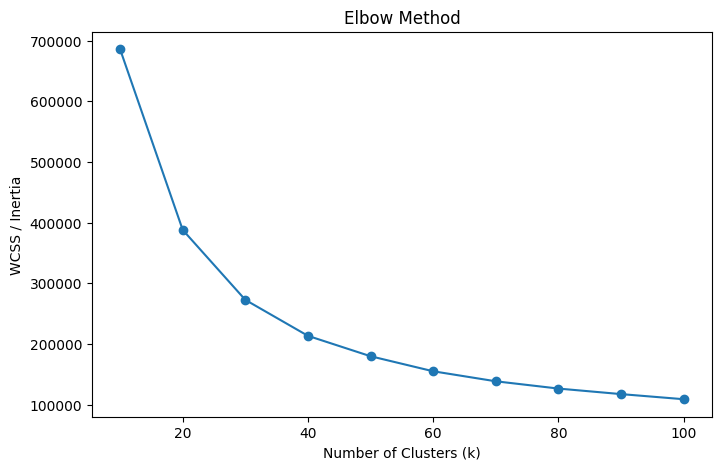

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train == 'Normal']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

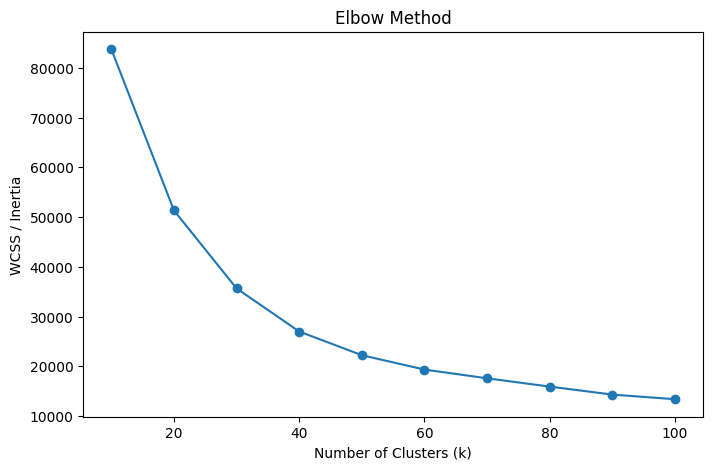

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_generic = X_train_scaled[y_train == 'Generic']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_generic)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

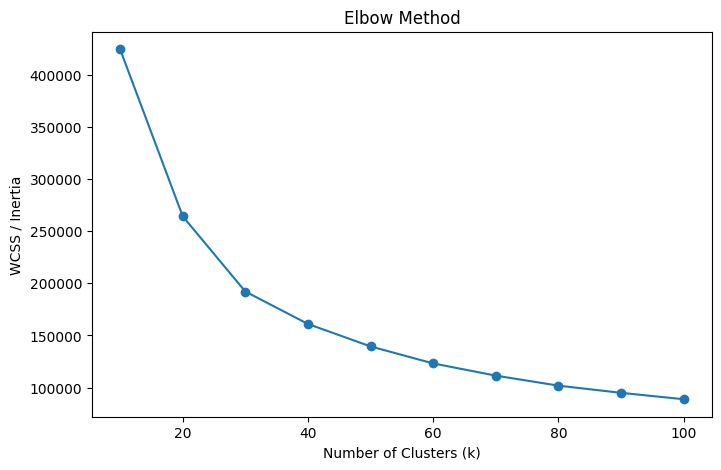

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_exploits = X_train_scaled[y_train == 'Exploits']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_exploits)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
def kmeans_undersample(
    X,
    y,
    sampling_strategy,
    cluster_strategy,
    random_state=42
):

    X_result, y_result = [], []

    unique_classes = np.unique(y)

    rng = np.random.RandomState(random_state)

    for cls in unique_classes:

        # =====================================================
        # AMBIL DATA PER CLASS
        # =====================================================
        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)

        X_cls = X[mask]

        # target jumlah setelah undersampling
        target_n = sampling_strategy.get(cls, len(X_cls))

        # jumlah cluster khusus tiap class
        n_cluster_cls = cluster_strategy.get(cls, 50)

        # =====================================================
        # MINORITY CLASS -> AMBIL SEMUA
        # =====================================================
        if len(X_cls) <= target_n:

            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))

        # =====================================================
        # MAJORITY CLASS -> KMEANS CLUSTER SAMPLING
        # =====================================================
        else:

            print(f"\nClass : {cls}")
            print(f"Original samples : {len(X_cls)}")
            print(f"Target samples   : {target_n}")
            print(f"Clusters used    : {n_cluster_cls}")

            # KMeans clustering
            km = KMeans(
                n_clusters=n_cluster_cls,
                random_state=random_state,
                n_init=10,
                max_iter=300
            )

            cluster_labels = km.fit_predict(X_cls)

            # jumlah sampel yang diambil per cluster
            samples_per_cluster = target_n // n_cluster_cls

            selected_indices = []

            # =====================================================
            # SAMPLING TIAP CLUSTER
            # =====================================================
            for cluster_id in range(n_cluster_cls):

                cluster_idx = np.where(cluster_labels == cluster_id)[0]

                # jika isi cluster <= target per cluster
                if len(cluster_idx) <= samples_per_cluster:

                    selected_indices.extend(cluster_idx)

                else:

                    chosen = rng.choice(
                        cluster_idx,
                        size=samples_per_cluster,
                        replace=False
                    )

                    selected_indices.extend(chosen)

            selected_indices = np.array(selected_indices)

            # =====================================================
            # JIKA JUMLAH MASIH KURANG
            # =====================================================
            if len(selected_indices) < target_n:

                remaining = np.setdiff1d(
                    np.arange(len(X_cls)),
                    selected_indices
                )

                extra = rng.choice(
                    remaining,
                    size=target_n - len(selected_indices),
                    replace=False
                )

                selected_indices = np.concatenate([
                    selected_indices,
                    extra
                ])

            X_result.append(X_cls[selected_indices])

            y_result.extend([cls] * len(selected_indices))

    # =====================================================
    # GABUNGKAN SEMUA CLASS
    # =====================================================
    X_out = np.vstack(X_result)
    y_out = np.array(y_result)

    return X_out, y_out


# =========================================================
# STEP 1 : KMEANS CLUSTER-BASED UNDERSAMPLING
# =========================================================

print("Step 1: KMeans Cluster-Based Undersampling")

sampling_strategy_under = {

    'Normal': 20000,
    'Generic': 20000,
    'Exploits': 20000,

}

# jumlah cluster optimal tiap class
cluster_strategy = {

    'Normal': 40,
    'Generic': 40,
    'Exploits': 40

}

X_under, y_under = kmeans_undersample(

    X_train_scaled,
    y_train,

    sampling_strategy=sampling_strategy_under,

    cluster_strategy=cluster_strategy,

    random_state=42
)

print("\nAfter KMeans Undersampling:")
print(Counter(y_under))


# =========================================================
# STEP 2 : BORDERLINE SMOTE
# =========================================================

print("\nStep 2: BorderlineSMOTE")

smote = BorderlineSMOTE(

    kind='borderline-2',

    sampling_strategy={

        'DoS': 15000,
        'Reconnaissance': 15000,

        'Analysis': 10000,
        'Backdoor': 10000,
        'Shellcode': 10000,

        'Worms': 5000

    },

    k_neighbors=3,
    random_state=42
)

X_res, y_res = smote.fit_resample(X_under, y_under)

print("\nAfter BorderlineSMOTE:")
print(Counter(y_res))

Step 1: KMeans Cluster-Based Undersampling

Class : Exploits
Original samples : 33393
Target samples   : 20000
Clusters used    : 40

Class : Generic
Original samples : 40000
Target samples   : 20000
Clusters used    : 40

Class : Normal
Original samples : 56000
Target samples   : 20000
Clusters used    : 40

After KMeans Undersampling:
Counter({np.str_('Exploits'): 20000, np.str_('Generic'): 20000, np.str_('Normal'): 20000, np.str_('Fuzzers'): 18184, np.str_('DoS'): 12264, np.str_('Reconnaissance'): 10491, np.str_('Analysis'): 2000, np.str_('Backdoor'): 1746, np.str_('Shellcode'): 1133, np.str_('Worms'): 130})

Step 2: BorderlineSMOTE

After BorderlineSMOTE:
Counter({np.str_('Exploits'): 20000, np.str_('Generic'): 20000, np.str_('Normal'): 20000, np.str_('Fuzzers'): 18184, np.str_('DoS'): 15000, np.str_('Reconnaissance'): 15000, np.str_('Analysis'): 10000, np.str_('Backdoor'): 10000, np.str_('Shellcode'): 10000, np.str_('Worms'): 5000})


## 7. XGBoost dengan Hybrid Sampling (Full Features)

In [ ]:
y_res_encoded = label_encoder.transform(y_res)

model_xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb.fit(X_res, y_res_encoded)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=== XGBoost + Hybrid Sampling (All Features) ===")
print(classification_report(y_test_encoded, y_pred_xgb,
                             target_names=label_encoder.classes_))

=== XGBoost + Hybrid Sampling (All Features) ===
                precision    recall  f1-score   support

      Analysis       0.06      0.32      0.11       677
      Backdoor       0.05      0.37      0.09       583
           DoS       0.42      0.31      0.35      4089
      Exploits       0.77      0.64      0.70     11132
       Fuzzers       0.26      0.67      0.37      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.98      0.64      0.77     37000
Reconnaissance       0.86      0.84      0.85      3496
     Shellcode       0.28      0.86      0.42       378
         Worms       0.59      0.52      0.55        44

      accuracy                           0.70     82332
     macro avg       0.53      0.61      0.52     82332
  weighted avg       0.85      0.70      0.75     82332



## 8. SHAP Analysis


Calculating SHAP values from TRAINING set (X_res)...
Note: SHAP dihitung dari training set agar tidak terjadi information leakage
SHAP values shape: (5000, 42, 10)
Generating SHAP summary plot...


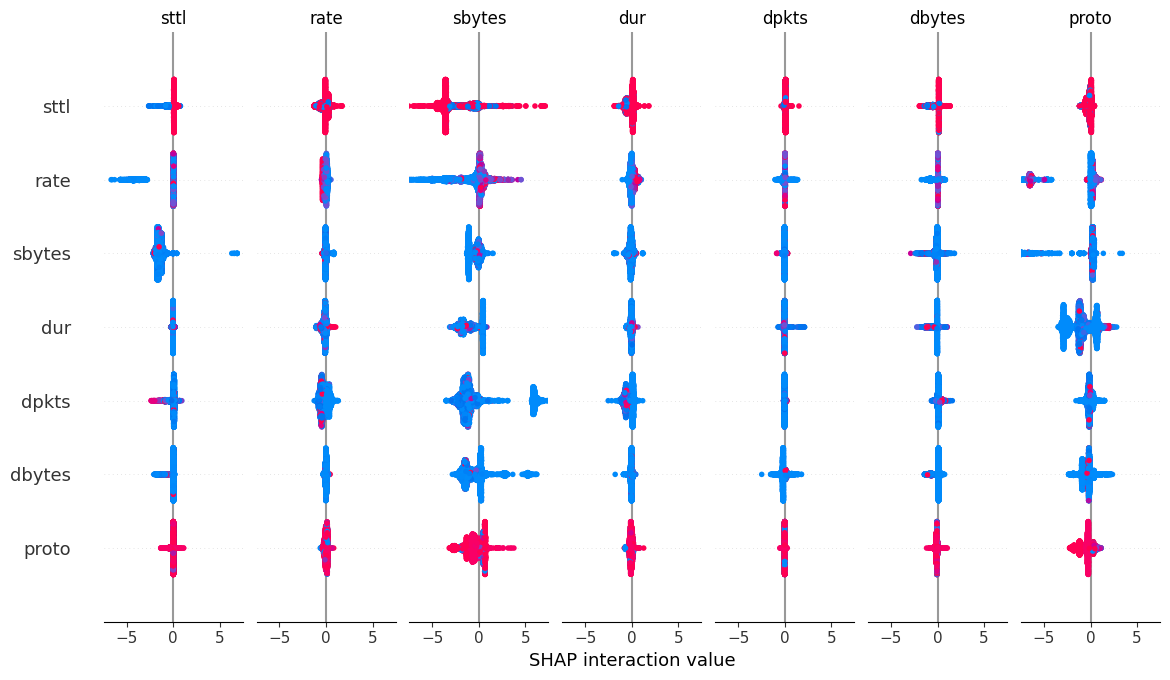

In [ ]:
import shap

print("Calculating SHAP values from TRAINING set (X_res)...")
print("Note: SHAP dihitung dari training set agar tidak terjadi information leakage")

explainer = shap.TreeExplainer(model_xgb)

# FIX: gunakan X_res (training set), BUKAN X_test_scaled
# Gunakan subsample agar lebih cepat jika data besar
shap_sample_size = min(5000, X_res.shape[0])
np.random.seed(42)
shap_indices = np.random.choice(X_res.shape[0], shap_sample_size, replace=False)
X_shap = X_res[shap_indices]

shap_values = explainer.shap_values(X_shap)

feature_names = X_train.columns.tolist()

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  class_names=label_encoder.classes_)

## 9. Feature Ranking dari SHAP

In [ ]:
shap_array = np.array(shap_values)

# Handle shape: bisa (n_classes, n_samples, n_features) atau (n_samples, n_features, n_classes)
if shap_array.ndim == 3:
    if shap_array.shape[0] == len(label_encoder.classes_):
        # Shape: (n_classes, n_samples, n_features) -> average over classes and samples
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))
    else:
        # Shape: (n_samples, n_features, n_classes) -> average over samples and classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

feature_importance = dict(zip(feature_names, mean_abs_shap))
sorted_feature_importance = sorted(feature_importance.items(),
                                    key=lambda x: x[1], reverse=True)

print("\nTop 15 Features by Mean |SHAP| (from training set):")
for i, (feat, imp) in enumerate(sorted_feature_importance[:15], 1):
    print(f"{i:2d}. {feat}: {imp:.4f}")


Top 15 Features by Mean |SHAP| (from training set):
 1. smean: 0.6031
 2. sbytes: 0.5957
 3. proto: 0.4538
 4. service: 0.4347
 5. ct_dst_src_ltm: 0.3378
 6. sttl: 0.3074
 7. ct_srv_dst: 0.2754
 8. ct_srv_src: 0.2306
 9. ct_src_dport_ltm: 0.2232
10. sloss: 0.1712
11. ct_dst_sport_ltm: 0.1509
12. dbytes: 0.1333
13. ct_src_ltm: 0.1205
14. dmean: 0.1167
15. dloss: 0.1157


## 10. Retrain dengan Top N Features
### Pipeline konsisten: SHAP (dari train) → filter fitur → scale → KMeans Undersample → SMOTE → train

In [ ]:
# =====================================================
# CLUSTER STRATEGY HASIL ELBOW
# =====================================================

cluster_strategy = {

    'Normal': 40,
    'Generic': 40,
    'Exploits': 40

}

results = {}
all_preds = {}

for top_n in [10, 20, 30]:

    print(f"\n{'='*55}")
    print(f" Processing Top {top_n} Features")
    print(f"{'='*55}")

    # =====================================================
    # TOP FEATURES
    # =====================================================

    top_features = [
        feat for feat, _ in sorted_feature_importance[:top_n]
    ]

    print(f"  Features: {top_features}")

    # =====================================================
    # FILTER FEATURE
    # =====================================================

    X_train_top = X_train[top_features]
    X_test_top  = X_test[top_features]

    # =====================================================
    # SCALING
    # =====================================================

    scaler_top = StandardScaler()

    X_train_top_scaled = scaler_top.fit_transform(X_train_top)
    X_test_top_scaled  = scaler_top.transform(X_test_top)

    # =====================================================
    # KMEANS UNDERSAMPLING
    # =====================================================

    X_under_top, y_under_top = kmeans_undersample(

        X_train_top_scaled,
        y_train,

        sampling_strategy=sampling_strategy_under,

        cluster_strategy=cluster_strategy,

        random_state=42
    )

    print(f"  After KMeans Undersampling:")
    print(Counter(y_under_top))

    # =====================================================
    # BORDERLINE SMOTE
    # =====================================================

    smote_top = BorderlineSMOTE(

        kind='borderline-2',

        sampling_strategy={

            'DoS': 15000,
            'Reconnaissance': 15000,

            'Analysis': 10000,
            'Backdoor': 10000,
            'Shellcode': 10000,

            'Worms': 5000

        },

        k_neighbors=3,
        random_state=42
    )

    X_res_top, y_res_top = smote_top.fit_resample(
        X_under_top,
        y_under_top
    )

    print(f"  After SMOTE:")
    print(Counter(y_res_top))

    # =====================================================
    # ENCODE TARGET
    # =====================================================

    y_res_top_encoded = label_encoder.transform(y_res_top)

    # =====================================================
    # XGBOOST
    # =====================================================

    model_top = XGBClassifier(

        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,

        subsample=0.8,
        colsample_bytree=0.8,

        eval_metric='mlogloss',

        random_state=42,
        n_jobs=-1
    )

    model_top.fit(X_res_top, y_res_top_encoded)

    # =====================================================
    # PREDICTION
    # =====================================================

    y_pred_top = model_top.predict(X_test_top_scaled)

    all_preds[top_n] = {

        'y_pred': y_pred_top,
        'model': model_top,

        'X_test_scaled': X_test_top_scaled,

        'X_res': X_res_top,

        'y_res_encoded': y_res_top_encoded,

        'top_features': top_features,

        'scaler': scaler_top,
    }

    # =====================================================
    # EVALUATION
    # =====================================================

    report = classification_report(

        y_test_encoded,
        y_pred_top,

        target_names=label_encoder.classes_,

        output_dict=True
    )

    results[f'top_{top_n}'] = report

    print(f"\n  Classification Report (Top {top_n} Features):")

    print(classification_report(
        y_test_encoded,
        y_pred_top,

        target_names=label_encoder.classes_
    ))


 Processing Top 10 Features
  Features: ['smean', 'sbytes', 'proto', 'service', 'ct_dst_src_ltm', 'sttl', 'ct_srv_dst', 'ct_srv_src', 'ct_src_dport_ltm', 'sloss']

Class : Exploits
Original samples : 33393
Target samples   : 20000
Clusters used    : 40

Class : Generic
Original samples : 40000
Target samples   : 20000
Clusters used    : 40

Class : Normal
Original samples : 56000
Target samples   : 20000
Clusters used    : 40
  After KMeans Undersampling:
Counter({np.str_('Exploits'): 20000, np.str_('Generic'): 20000, np.str_('Normal'): 20000, np.str_('Fuzzers'): 18184, np.str_('DoS'): 12264, np.str_('Reconnaissance'): 10491, np.str_('Analysis'): 2000, np.str_('Backdoor'): 1746, np.str_('Shellcode'): 1133, np.str_('Worms'): 130})
  After SMOTE:
Counter({np.str_('Exploits'): 20000, np.str_('Generic'): 20000, np.str_('Normal'): 20000, np.str_('Fuzzers'): 18184, np.str_('DoS'): 15000, np.str_('Reconnaissance'): 15000, np.str_('Analysis'): 10000, np.str_('Backdoor'): 10000, np.str_('Shell

## 11. Hyperparameter Tuning (pada konfigurasi terbaik)

In [ ]:
# Ganti top_n_best sesuai hasil eksperimen di atas
top_n_best = 30

best_data = all_preds[top_n_best]
X_res_best        = best_data['X_res']
y_res_best_enc    = best_data['y_res_encoded']
X_test_best_scaled = best_data['X_test_scaled']

print(f"Data untuk tuning: {X_res_best.shape}")
print(f"Label distribution: {Counter(label_encoder.inverse_transform(y_res_best_enc))}")


Data untuk tuning: (143184, 30)
Label distribution: Counter({'Exploits': 20000, 'Generic': 20000, 'Normal': 20000, 'Fuzzers': 18184, 'DoS': 15000, 'Reconnaissance': 15000, 'Analysis': 10000, 'Backdoor': 10000, 'Shellcode': 10000, 'Worms': 5000})


In [ ]:
param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
}

xgb_tune = XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall_macro',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting RandomizedSearchCV...")
random_search.fit(X_res_best, y_res_best_enc)
print("Finished.")

best_model = random_search.best_estimator_
print("Best params:", random_search.best_params_)
print("Best recall_macro (CV):", random_search.best_score_)

y_pred_tuned = best_model.predict(X_test_best_scaled)

Starting RandomizedSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Finished.
Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best recall_macro (CV): 0.6859122739460823


## 12. Perbandingan Semua Model

In [ ]:
import pandas as pd

def get_summary(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred,
                                    target_names=label_encoder.classes_,
                                    output_dict=True)
    return {
        'Model': model_name,
        'Accuracy': round(report['accuracy'], 4),
        'F1 Macro': round(report['macro avg']['f1-score'], 4),
        'Recall Macro': round(report['macro avg']['recall'], 4),
        'F1 R2L': round(report.get('r2l', {}).get('f1-score', 0), 4),
        'F1 U2R': round(report.get('u2r', {}).get('f1-score', 0), 4),
    }

# Kumpulkan prediksi dari semua model
# y_pred_top di sini adalah prediksi dari iterasi top_n=30 (iterasi terakhir loop)
rows = [
    get_summary(y_test_encoded, y_pred_unbalanced,   'Baseline (No Sampling)'),
    get_summary(y_test_encoded, y_pred_xgb,           'Hybrid Sampling (All Fitur)'),
    get_summary(y_test_encoded, y_pred_top,            f'Hybrid + Top {top_n} Fitur (last loop)'),
    get_summary(y_test_encoded, y_pred_tuned,          f'Hybrid + Top {top_n_best} + Tuning'),
]

df_compare = pd.DataFrame(rows)
print("\n=== Perbandingan Semua Model ===")
print(df_compare.to_string(index=False))



=== Perbandingan Semua Model ===
                            Model  Accuracy  F1 Macro  Recall Macro  F1 R2L  F1 U2R
           Baseline (No Sampling)    0.7625    0.5022        0.5372       0       0
      Hybrid Sampling (All Fitur)    0.7045    0.5207        0.6132       0       0
Hybrid + Top 30 Fitur (last loop)    0.7030    0.5200        0.6054       0       0
         Hybrid + Top 30 + Tuning    0.6886    0.4938        0.6061       0       0
